In [44]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.6f}'.format)

# Random Forest — Attribute Effects via SHAP

This notebook measures the impact of each attribute on the outcome of the incident (`severity`) using **SHAP Global E[φ_k]** as the effect metric.

SHAP is computed on the **probability scale**, which ensures that its values are directly comparable to the **Average Marginal Effects (AMEs) from logistic regression**: both express the average change in P(severity = 1) attributed to each variable.

> **Warning — Random Forest pitfall:** as with XGBoost, the default `TreeExplainer` may return SHAP values on either the log-odds or probability scale depending on the SHAP version and configuration. For `RandomForestClassifier` in sklearn, the safest and most stable approach is to use `KernelExplainer` with an explicit `predict_proba` wrapper, ensuring that φ_k(i) are unequivocally on the probability scale.


In [45]:
url_train = "../../database/completo/final/df_train.csv"
url_test = "../../database/completo/final/df_test.csv"

# carrega dados
df_train = pd.read_csv(url_train, sep=",", encoding="UTF-8")
df_test = pd.read_csv(url_test, sep=",", encoding="UTF-8")

In [46]:
X_train = df_train.drop(columns=["grave", "ano"])
y_train = df_train["grave"]

X_test = df_test.drop(columns=["grave", "ano"])
y_test = df_test["grave"]

In [47]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' compensa o desbalanceamento de classes,
# ponderando cada observacao por n_amostras / (n_classes * n_amostras_classe).
# Equivalente ao scale_pos_weight do XGBoost e ao class_weight='balanced'
# da arvore de decisao.
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [48]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n=== Metricas (Teste 2025) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Metricas (Teste 2025) ===
Accuracy : 0.6270
Precision: 0.1802
Recall   : 0.4634
F1-score : 0.2595
AUC      : 0.5743

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.65      0.75     62109
           1       0.18      0.46      0.26     10201

    accuracy                           0.63     72310
   macro avg       0.53      0.56      0.51     72310
weighted avg       0.78      0.63      0.68     72310



In [49]:
# ============================================================
# SHAP na escala de PROBABILIDADE -- TreeExplainer
# ============================================================

X_background = shap.sample(X_train, 500, random_state=42)

explainer = shap.TreeExplainer(
    rf,
    data=X_background,
    model_output="probability",
    feature_perturbation="interventional"
)

print("Calculando SHAP values...")
X_test_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
n_obs      = len(X_test_sample)
n_features = X_test_sample.shape[1]

shap_values = explainer.shap_values(X_test_sample)
raw = np.array(shap_values)

print(f"Formato bruto retornado pelo TreeExplainer: {raw.shape}")
print(f"n_obs={n_obs}, n_features={n_features}")

# ------------------------------------------------------------
# Normaliza para shape (n_amostras, n_features) -- classe 1
# ------------------------------------------------------------
if isinstance(shap_values, list):
    # lista [classe_0, classe_1]
    shap_array = np.array(shap_values[1])
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[0] == 2:
    # (n_classes, n_amostras, n_features)
    shap_array = raw[1]
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[2] == 2:
    # (n_amostras, n_features, n_classes)
    shap_array = raw[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    # (n_amostras, n_features) ou (n_features, n_amostras) -- versoes recentes
    shap_array = raw
    expected_value = (
        explainer.expected_value[1]
        if hasattr(explainer.expected_value, "__len__")
        else explainer.expected_value
    )

# Garante orientacao (n_amostras, n_features):
# se o array chegou transposto (n_features, n_amostras), corrige.
if shap_array.shape == (n_features, n_obs):
    print("[AVISO] array transposto detectado -- corrigindo orientacao.")
    shap_array = shap_array.T

print(f"Formato dos SHAP values (classe 1): {shap_array.shape}")
print(f"Valor esperado (phi_0):             {expected_value:.6f}")

Calculando SHAP values...


100%|===================| 3987/4000 [04:30<00:00]        

Formato bruto retornado pelo TreeExplainer: (2000, 20, 2)
n_obs=2000, n_features=20
Formato dos SHAP values (classe 1): (2000, 20)
Valor esperado (phi_0):             0.401447


In [50]:
# ============================================================
# VALIDACAO da escala de probabilidade
# ============================================================
# Propriedade de eficiencia do SHAP:
#   phi_0 + sum_k(phi_k(i)) = P_hat(i) = P(gravidade=1 | X=x_i)
#
# Desvio baixo confirma que os valores SHAP estao na escala
# de probabilidade e sao comparaveis aos AMEs da regressao.

shap_reconstructed = expected_value + shap_array.sum(axis=1)
prob_real = rf.predict_proba(X_test_sample)[:, 1]

max_desvio  = np.abs(shap_reconstructed - prob_real).max()
mean_desvio = np.abs(shap_reconstructed - prob_real).mean()

print(f"phi_0 (valor esperado):                         {expected_value:.6f}")
print(f"Desvio maximo  |phi_0 + sum(phi_k) - P_hat|:   {max_desvio:.2e}")
print(f"Desvio medio   |phi_0 + sum(phi_k) - P_hat|:   {mean_desvio:.2e}")

if max_desvio < 1e-3:
    print("\n[OK] SHAP na escala de probabilidade -- comparavel aos AMEs da regressao logistica.")
else:
    print("\n[ATENCAO] Desvio acima do esperado. Verifique a configuracao do explainer.")

phi_0 (valor esperado):                         0.401447
Desvio maximo  |phi_0 + sum(phi_k) - P_hat|:   5.13e-04
Desvio medio   |phi_0 + sum(phi_k) - P_hat|:   5.15e-07

[OK] SHAP na escala de probabilidade -- comparavel aos AMEs da regressao logistica.


In [51]:
# ============================================================
# SHAP GLOBAL -- E[phi_k]
# ============================================================
# Medida de efeito do Random Forest, na mesma escala e com a
# mesma interpretacao dos AMEs da regressao logistica:
#   "variacao media em P(gravidade=1) atribuida a variavel k"

# E[phi_k]: efeito medio com sinal -- use para comparar entre modelos
shap_global_mean = pd.Series(
    shap_array.mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_global_E[phi_k]"
)

# E[|phi_k|]: importancia absoluta -- use apenas para ranqueamento
# (perde o sinal do efeito; nao usar para comparacao com AME)
shap_global_abs = pd.Series(
    np.abs(shap_array).mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_importancia_E[|phi_k|]"
)

resultado = pd.concat([shap_global_mean, shap_global_abs], axis=1)
resultado = resultado.sort_values(by="SHAP_importancia_E[|phi_k|]", ascending=False)

print("\n=== Impacto dos atributos na probabilidade do desfecho (Random Forest) ===")
print("SHAP_global_E[phi_k]        -> efeito medio com sinal, em unidades de probabilidade")
print("SHAP_importancia_E[|phi_k|] -> importancia absoluta, para ranqueamento")
print()
print(resultado.to_string())


=== Impacto dos atributos na probabilidade do desfecho (Random Forest) ===
SHAP_global_E[phi_k]        -> efeito medio com sinal, em unidades de probabilidade
SHAP_importancia_E[|phi_k|] -> importancia absoluta, para ranqueamento

                    SHAP_global_E[phi_k]  SHAP_importancia_E[|phi_k|]
uf_br_km                        0.031093                     0.126565
vel_max                         0.002770                     0.021059
turno_sin                      -0.002751                     0.013101
frequencia                      0.002876                     0.011453
tipo_pista                      0.000035                     0.008554
uso_solo                       -0.000569                     0.008317
pista_molhada                   0.002285                     0.006233
distancia_radar_m               0.000640                     0.005523
turno_cos                      -0.001374                     0.005212
visibilidade_ruim               0.001680                     0.00513

In [52]:
# ============================================================
# INTERPRETACAO DOS EFEITOS
# ============================================================
print("\n=== Interpretacao dos efeitos ===")
print("Variacao media em P(gravidade=1) atribuida a cada variavel.\n")

for var, row in resultado.iterrows():
    impacto     = row["SHAP_global_E[phi_k]"]
    importancia = row["SHAP_importancia_E[|phi_k|]"]

    if importancia < 1e-8:
        print(f"{var:35s}: SEM EFEITO")
    elif impacto > 0:
        print(f"{var:35s}: AUMENTA a probabilidade em +{impacto:.4f} (em media)")
    else:
        print(f"{var:35s}: REDUZ  a probabilidade em {impacto:.4f} (em media)")


=== Interpretacao dos efeitos ===
Variacao media em P(gravidade=1) atribuida a cada variavel.

uf_br_km                           : AUMENTA a probabilidade em +0.0311 (em media)
vel_max                            : AUMENTA a probabilidade em +0.0028 (em media)
turno_sin                          : REDUZ  a probabilidade em -0.0028 (em media)
frequencia                         : AUMENTA a probabilidade em +0.0029 (em media)
tipo_pista                         : AUMENTA a probabilidade em +0.0000 (em media)
uso_solo                           : REDUZ  a probabilidade em -0.0006 (em media)
pista_molhada                      : AUMENTA a probabilidade em +0.0023 (em media)
distancia_radar_m                  : AUMENTA a probabilidade em +0.0006 (em media)
turno_cos                          : REDUZ  a probabilidade em -0.0014 (em media)
visibilidade_ruim                  : AUMENTA a probabilidade em +0.0017 (em media)
dia_semana_sin                     : REDUZ  a probabilidade em -0.0002 (em me

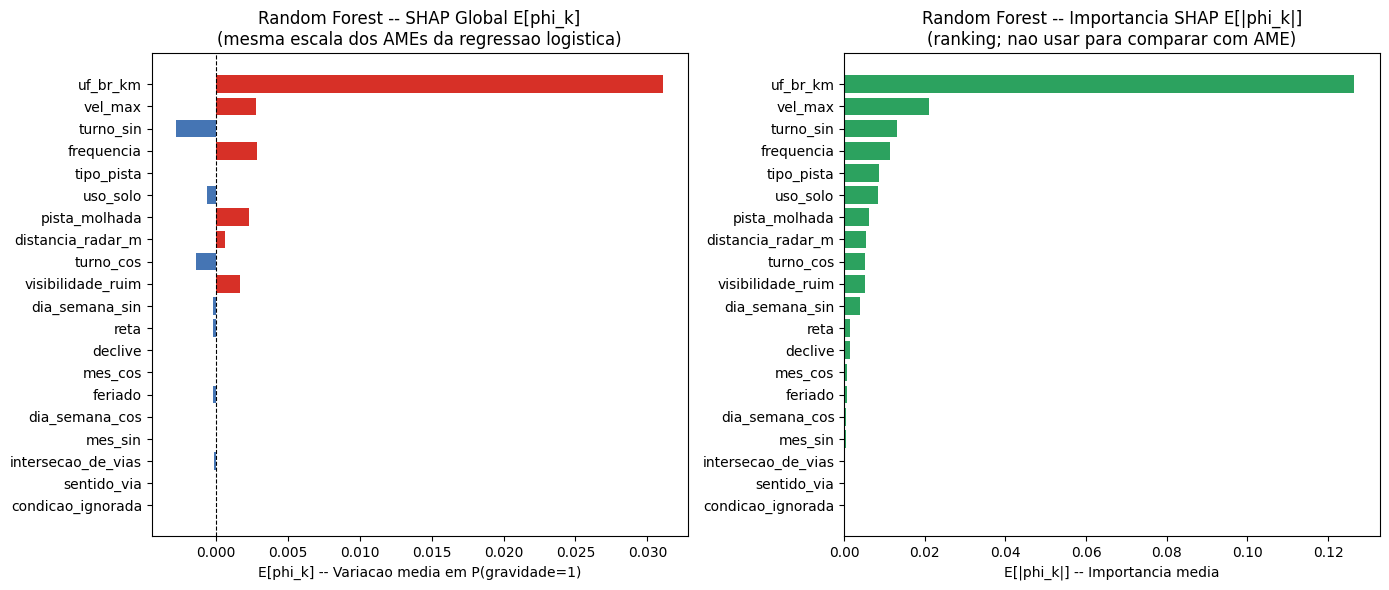

Grafico salvo em rf_shap_efeitos.png


In [53]:
# ============================================================
# VISUALIZACOES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: efeito medio com sinal (mesma leitura que AME)
cores = ['#d73027' if v > 0 else '#4575b4' for v in resultado["SHAP_global_E[phi_k]"]]
axes[0].barh(resultado.index, resultado["SHAP_global_E[phi_k]"], color=cores)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("E[phi_k] -- Variacao media em P(gravidade=1)")
axes[0].set_title("Random Forest -- SHAP Global E[phi_k]\n(mesma escala dos AMEs da regressao logistica)")
axes[0].invert_yaxis()

# Grafico 2: importancia absoluta (ranking)
axes[1].barh(resultado.index, resultado["SHAP_importancia_E[|phi_k|]"], color='#2ca25f')
axes[1].set_xlabel("E[|phi_k|] -- Importancia media")
axes[1].set_title("Random Forest -- Importancia SHAP E[|phi_k|]\n(ranking; nao usar para comparar com AME)")
axes[1].invert_yaxis()

plt.tight_layout()  
plt.savefig("rf_shap_efeitos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo em rf_shap_efeitos.png")

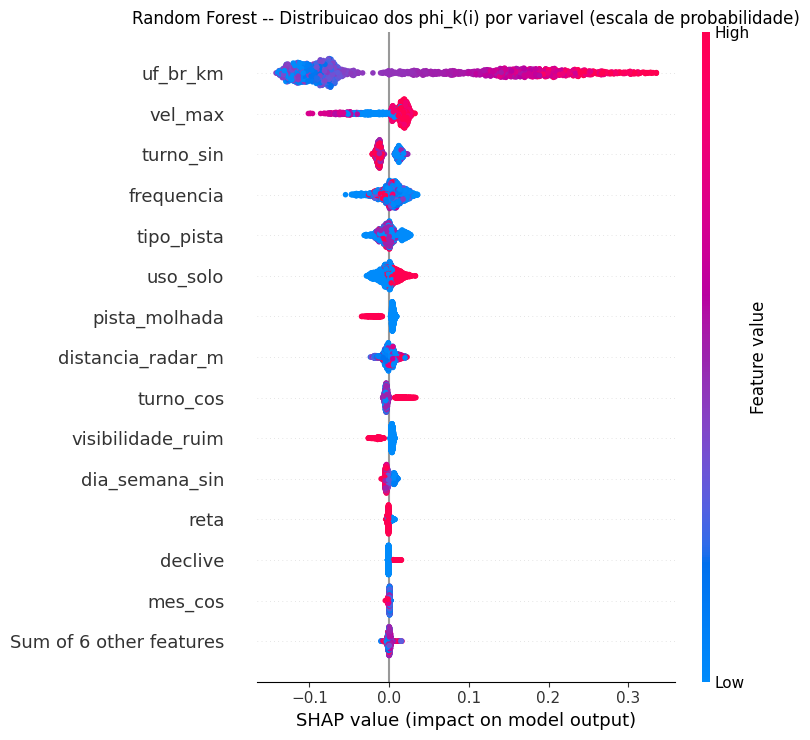

Beeswarm salvo em rf_shap_beeswarm.png


In [54]:
# ============================================================
# BEESWARM PLOT -- distribuicao local dos phi_k(i)
# ============================================================
# Revela heterogeneidade dos efeitos alem da media global.
# O eixo X esta em unidades de probabilidade.

shap_explanation = shap.Explanation(
    values=shap_array,
    base_values=expected_value,
    data=X_test_sample.values,
    feature_names=list(X_test_sample.columns)
)

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("Random Forest -- Distribuicao dos phi_k(i) por variavel (escala de probabilidade)")
plt.tight_layout()
plt.savefig("rf_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm salvo em rf_shap_beeswarm.png")

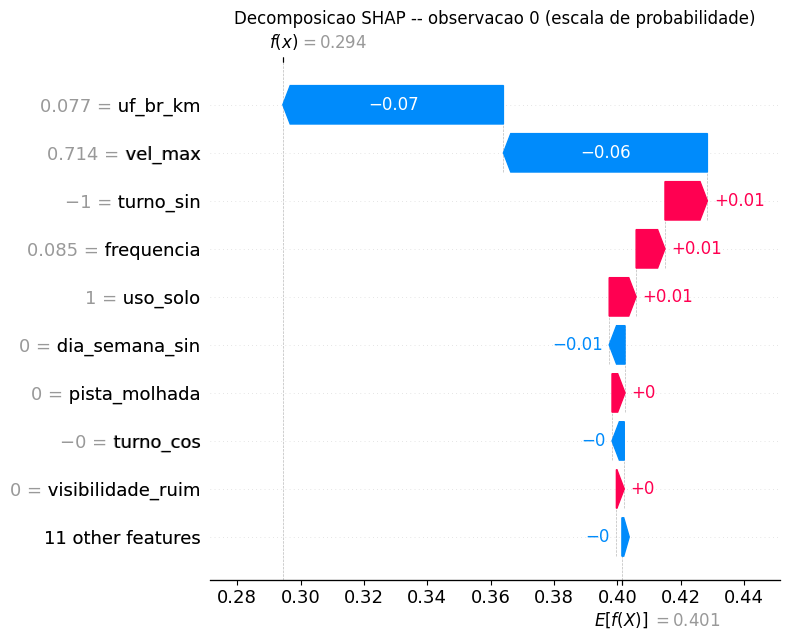

Waterfall salvo em rf_shap_waterfall.png


In [55]:
# ============================================================
# WATERFALL PLOT -- decomposicao de uma observacao individual
# ============================================================
# Mostra phi_0 + sum(phi_k(i)) = P_hat(i) para uma observacao.
# Util para auditar a escala e verificar a propriedade de eficiencia.

idx = 0  # altere para inspecionar outra observacao

plt.figure()
shap.plots.waterfall(shap_explanation[idx], show=False)
plt.title(f"Decomposicao SHAP -- observacao {idx} (escala de probabilidade)")
plt.tight_layout()
plt.savefig("rf_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall salvo em rf_shap_waterfall.png")

In [56]:
def rf_cyclic_analysis(shap_values, X, sin_name, cos_name):
    
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    
    phi_sin = shap_values[:, idx_sin]
    phi_cos = shap_values[:, idx_cos]
    
    # 🔹 1. Importância (análogo ao SHAP |φ|)
    importance = np.mean(np.sqrt(phi_sin**2 + phi_cos**2))
    
    # 🔹 2. Direção média (vetor médio)
    mean_sin = np.mean(phi_sin)
    mean_cos = np.mean(phi_cos)
    
    direction_amplitude = np.sqrt(mean_sin**2 + mean_cos**2)
    
    # 🔹 3. Variabilidade (quanto o efeito oscila)
    variability = np.std(phi_sin + phi_cos)
    
    return {
        "importance_cyclic": importance,
        "direction_amplitude": direction_amplitude,
        "mean_sin": mean_sin,
        "mean_cos": mean_cos,
        "variability": variability
    }

In [57]:
print(rf_cyclic_analysis(shap_values, X_train, "turno_sin", "turno_cos"))
print(rf_cyclic_analysis(shap_values, X_train, "dia_semana_sin", "dia_semana_cos"))
print(rf_cyclic_analysis(shap_values, X_train, "mes_sin", "mes_cos"))

{'importance_cyclic': np.float64(0.014562209662845714), 'direction_amplitude': np.float64(1.4677905719579624e-11), 'mean_sin': np.float64(-1.3335490082859446e-11), 'mean_cos': np.float64(-6.132342175941066e-12), 'variability': np.float64(0.018323779681123094)}
{'importance_cyclic': np.float64(0.003953560985380657), 'direction_amplitude': np.float64(5.1237948487154175e-12), 'mean_sin': np.float64(-4.765208540258304e-12), 'mean_cos': np.float64(1.883098834254849e-12), 'variability': np.float64(0.0047089040867366976)}
{'importance_cyclic': np.float64(0.0009564719615644746), 'direction_amplitude': np.float64(1.9299886349263014e-12), 'mean_sin': np.float64(9.952113090875778e-13), 'mean_cos': np.float64(-1.6536053281266597e-12), 'variability': np.float64(0.0011687244078085457)}


In [58]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rf_cycle_labels(shap_values, X, sin_name, cos_name, labels, offset=0):
    
    period = len(labels)
    
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    
    phi_sin = shap_values[:, idx_sin]
    phi_cos = shap_values[:, idx_cos]
    
    v = np.arange(0, period)
    theta = 2 * np.pi * (v - offset) / period
    
    effect = []
    for t in theta:
        proj = phi_sin * np.sin(t) + phi_cos * np.cos(t)
        effect.append(np.mean(proj))
    
    plt.figure(figsize=(8,4))
    plt.plot(labels, effect, marker='o')
    plt.axhline(0)
    plt.title(f"Ciclo RF-SHAP: {sin_name[:-4]}")
    plt.ylabel("Efeito médio (SHAP)")
    plt.grid()
    plt.xticks(rotation=30)
    plt.show()

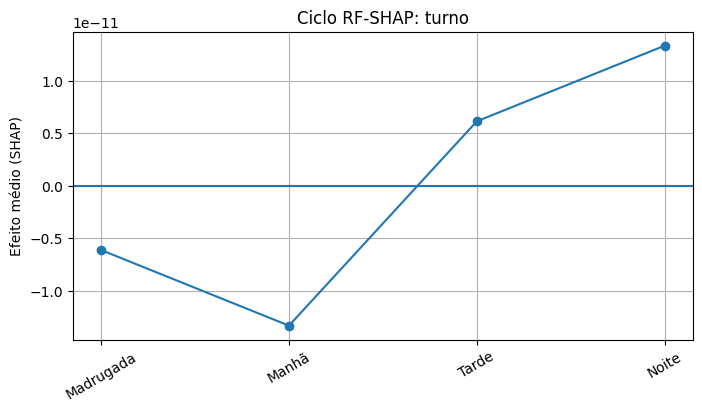

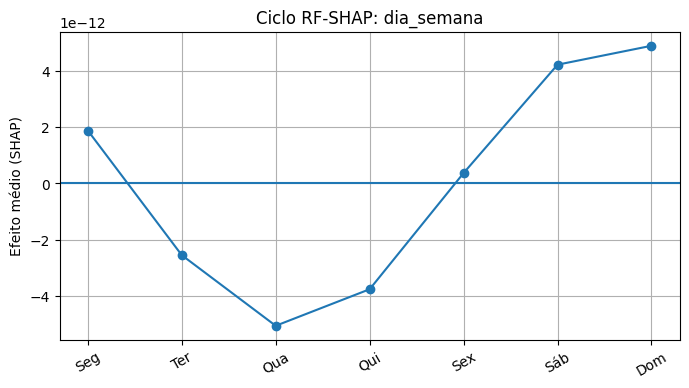

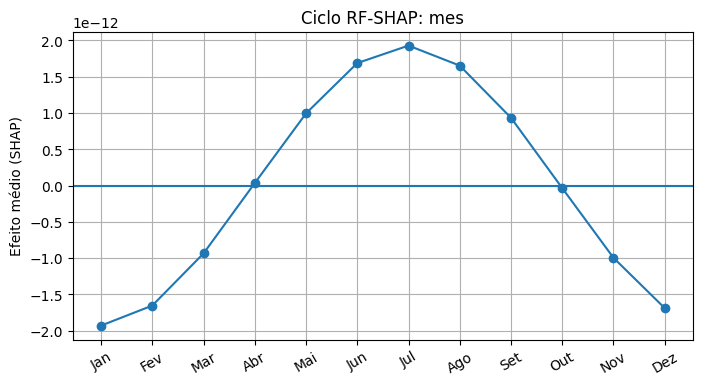

In [59]:
plot_rf_cycle_labels(
    shap_values, X_train,
    "turno_sin", "turno_cos",
    ["Madrugada", "Manhã", "Tarde", "Noite"]
)

plot_rf_cycle_labels(
    shap_values, X_train,
    "dia_semana_sin", "dia_semana_cos",
    ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
)

plot_rf_cycle_labels(
    shap_values, X_train,
    "mes_sin", "mes_cos",
    ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
     "Jul", "Ago", "Set", "Out", "Nov", "Dez"],
    offset=1
)

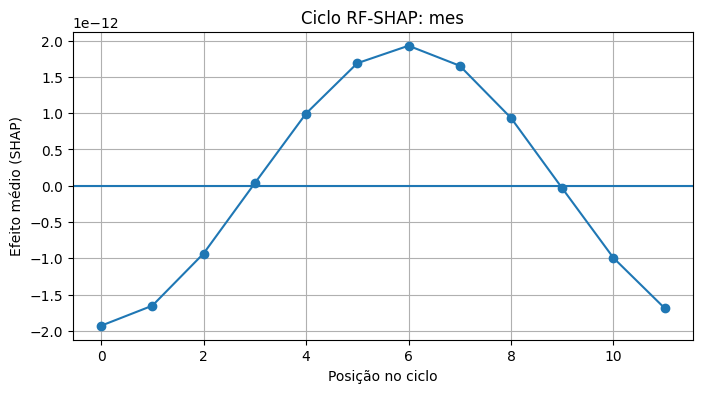

In [60]:
plot_rf_cycle(
    shap_values,
    X_train,
    "mes_sin",
    "mes_cos",
    period=12,
    offset=1
)

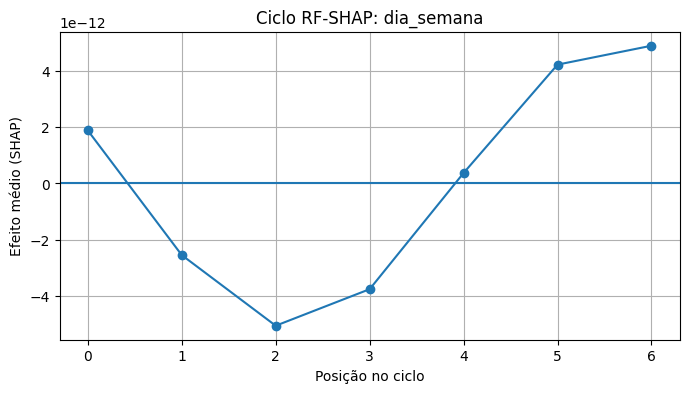

In [61]:
plot_rf_cycle(
    shap_values,
    X_train,
    "dia_semana_sin",
    "dia_semana_cos",
    period=7,
)